# Boom model training — oversize_frac onlyStripped-down version of the full pipeline, predicting only `oversize_frac` (fraction of total ejecta mass from fragments > 120mm diameter).

In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import lightgbm as lgb
import shap
from scipy.special import expit, logit
from sklearn.linear_model import RidgeCV
from sklearn.metrics import f1_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

### Feature helpers

In [ ]:
_LOG_SOURCES = {
    "pi_strength": "log_pi_strength",
    "coupling": "log_coupling",
    "porosity": "log_porosity",
    "shape_factor": "log_shape",
    "pi_threshold_oversize": "log_pi_threshold_oversize",
    "energy": "log_energy",
    "strength": "log_strength",
    "gravity": "log_gravity",
    "atmosphere": "log_atmosphere",
}
_EPS = 1e-6

_DERIVED_SOURCES = {
    "log_pi_threshold_oversize_sq": ("log_pi_threshold_oversize", lambda x: x ** 2),
    "log_pi_threshold_oversize_cu": ("log_pi_threshold_oversize", lambda x: x ** 3),
    "log_pi_strength_sq": ("log_pi_strength", lambda x: x ** 2),
    "log_pi_strength_cu": ("log_pi_strength", lambda x: x ** 3),
    "log_shape_sq": ("log_shape", lambda x: x ** 2),
    "log_shape_cu": ("log_shape", lambda x: x ** 3),
    "log_coupling_sq": ("log_coupling", lambda x: x ** 2),
    "log_porosity_sq": ("log_porosity", lambda x: x ** 2),
    "log_energy_x_strength": (("log_energy", "log_strength"), lambda a, b: a * b),
    "log_atm_x_strength": (("log_atmosphere", "log_strength"), lambda a, b: a * b),
    "log_strength_x_coupling": (("log_strength", "log_coupling"), lambda a, b: a * b),
    "log_porosity_x_strength": (("log_porosity", "log_strength"), lambda a, b: a * b),
    "log_atm_x_cos": (("log_atmosphere", "cos_angle"), lambda a, b: a * b),
}


def build_geometry(df: pd.DataFrame) -> pd.DataFrame:
    X = df.copy()
    X["L_char"] = (X["energy"] / (X["atmosphere"] * X["gravity"])) ** 0.25
    X["pi_strength"] = X["strength"] / (X["atmosphere"] * X["gravity"] * X["L_char"])
    X["sin_angle"] = np.sin(X["angle_rad"])
    X["cos_angle"] = np.cos(X["angle_rad"])
    X["D_oversize"] = 120.0
    X["pi_threshold_oversize"] = X["D_oversize"] / X["L_char"]
    return X


class ZLogFeatureTransforms:
    def __init__(self):
        self._scalers: dict[str, StandardScaler] = {}
        self._derived_scalers: dict[str, StandardScaler] = {}

    def _raw_logs(self, geom: pd.DataFrame) -> pd.DataFrame:
        logs = pd.DataFrame(index=geom.index)
        for source, log_col in _LOG_SOURCES.items():
            logs[log_col] = np.log(geom[source].clip(lower=_EPS))
        return logs

    def _compute_derived(self, X: pd.DataFrame, logs: pd.DataFrame) -> dict[str, np.ndarray]:
        raw = {}
        for name, spec in _DERIVED_SOURCES.items():
            src, fn = spec
            if isinstance(src, tuple):
                a = logs[src[0]].to_numpy() if src[0] in logs.columns else X[src[0]].to_numpy()
                b = logs[src[1]].to_numpy() if src[1] in logs.columns else X[src[1]].to_numpy()
                raw[name] = fn(a, b)
            else:
                vals = logs[src].to_numpy() if src in logs.columns else X[src].to_numpy()
                raw[name] = fn(vals)
        return raw

    def fit(self, geom: pd.DataFrame) -> "ZLogFeatureTransforms":
        logs = self._raw_logs(geom)
        for log_col in logs:
            self._scalers[log_col] = StandardScaler().fit(logs[[log_col]].to_numpy())
        z_logs = pd.DataFrame(index=geom.index)
        for log_col in logs:
            z_logs[log_col] = self._scalers[log_col].transform(logs[[log_col]].to_numpy()).ravel()
        X_temp = geom.copy()
        X_temp["sin_angle"] = np.sin(geom["angle_rad"])
        X_temp["cos_angle"] = np.cos(geom["angle_rad"])
        for log_col in z_logs:
            X_temp[log_col] = z_logs[log_col]
        derived_raw = self._compute_derived(X_temp, z_logs)
        for name, vals in derived_raw.items():
            self._derived_scalers[name] = StandardScaler().fit(vals.reshape(-1, 1))
        return self

    def transform(self, geom: pd.DataFrame) -> pd.DataFrame:
        X = geom.copy()
        logs = self._raw_logs(geom)
        for log_col in logs:
            raw_log = logs[[log_col]].to_numpy()
            X[f"{log_col}_raw"] = raw_log.ravel()
            X[log_col] = self._scalers[log_col].transform(raw_log).ravel()
        X["sin_angle"] = np.sin(geom["angle_rad"])
        X["cos_angle"] = np.cos(geom["angle_rad"])
        z_logs = pd.DataFrame(index=geom.index)
        for log_col in logs:
            z_logs[log_col] = X[log_col]
        derived_raw = self._compute_derived(X, z_logs)
        for name, vals in derived_raw.items():
            X[name] = self._derived_scalers[name].transform(vals.reshape(-1, 1)).ravel()
        return X


def build_features(df: pd.DataFrame, z_log: ZLogFeatureTransforms) -> pd.DataFrame:
    return z_log.transform(build_geometry(df))


def transform_target_oversize_frac(y: pd.DataFrame) -> pd.Series:
    return logit(y["oversize_frac"].clip(_EPS, 1 - _EPS))


def invert_target_oversize_frac(logit_oversize_frac: pd.Series) -> pd.Series:
    return expit(logit_oversize_frac)

### Model helpers

In [ ]:
LINEAR_FEATURES = [
    "log_pi_strength",
    "log_pi_strength_sq",
    "log_pi_strength_cu",
    "log_coupling",
    "log_coupling_sq",
    "log_porosity",
    "log_porosity_sq",
    "log_shape",
    "log_shape_sq",
    "log_shape_cu",
    "log_pi_threshold_oversize",
    "log_pi_threshold_oversize_sq",
    "log_pi_threshold_oversize_cu",
    "log_energy",
    "log_strength",
    "log_gravity",
    "log_atmosphere",
    "sin_angle",
    "cos_angle",
    "log_energy_x_strength",
    "log_atm_x_strength",
    "log_strength_x_coupling",
    "log_porosity_x_strength",
    "log_atm_x_cos",
]

LGB_FEATURES = list(LINEAR_FEATURES)

TARGET = "logit_oversize_frac"


class HybridPhysicsModel:
    def __init__(self, linear_features, lgb_features, lgb_params=None):
        self.linear_features = linear_features
        self.lgb_features = lgb_features
        self.lgb_params = lgb_params or {
            "n_estimators": 500,
            "learning_rate": 0.05,
            "num_leaves": 31,
            "min_child_samples": 10,
            "reg_alpha": 0.1,
            "reg_lambda": 0.1,
            "verbose": -1,
        }
        self.baseline = None
        self.residual = None
        self.best_iteration_ = None

    def fit(self, X, y, eval_set=None, eval_names=None, eval_metric="l2", callbacks=None):
        self.baseline = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]).fit(X[self.linear_features], y)
        residuals = y - self.baseline.predict(X[self.linear_features])
        residual_eval_set = None
        if eval_set is not None:
            residual_eval_set = []
            for X_eval, y_eval in eval_set:
                residual_eval_set.append((
                    X_eval[self.lgb_features],
                    y_eval - self.baseline.predict(X_eval[self.linear_features]),
                ))
        self.residual = lgb.LGBMRegressor(**self.lgb_params).fit(
            X[self.lgb_features],
            residuals,
            eval_set=residual_eval_set,
            eval_names=eval_names,
            eval_metric=eval_metric,
            callbacks=callbacks,
        )
        self.best_iteration_ = getattr(self.residual, "best_iteration_", None)
        return self

    def predict(self, X):
        num_iteration = self.best_iteration_ if self.best_iteration_ else None
        return (
            self.baseline.predict(X[self.linear_features])
            + self.residual.predict(X[self.lgb_features], num_iteration=num_iteration)
        )

    def baseline_coefficients(self):
        return pd.Series(self.baseline.coef_, index=self.linear_features)

### Configuration

In [4]:
data_dir = "../forward_prediction"
n_splits = 5
seed = 42

### Load raw training data

In [5]:
X_raw = pd.read_csv(f"{data_dir}/train.csv").reset_index(drop=True)
y_raw = pd.read_csv(f"{data_dir}/train_labels.csv").reset_index(drop=True)
if len(X_raw) != len(y_raw):
    raise ValueError(
        f"{data_dir}/train.csv ({len(X_raw)} rows) and "
        f"{data_dir}/train_labels.csv ({len(y_raw)} rows) must align"
    )

### Feature engineering and transformed target

In [6]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

geom = build_geometry(X_raw)
z_log = ZLogFeatureTransforms().fit(geom)
X = build_features(X_raw, z_log)
y = transform_target_oversize_frac(y_raw)

X

,porosity,atmosphere,gravity,coupling,strength,shape_factor,energy,angle_rad,L_char,pi_strength,sin_angle,cos_angle,D_oversize,pi_threshold_oversize,log_pi_strength_raw,log_pi_strength,log_coupling_raw,log_coupling,log_porosity_raw,log_porosity,log_shape_raw,log_shape,log_pi_threshold_oversize_raw,log_pi_threshold_oversize,log_energy_raw,log_energy,log_strength_raw,log_strength,log_gravity_raw,log_gravity,log_atmosphere_raw,log_atmosphere
0,0.337215,0.781263,3.71,0.861258,1.305809,0.784028,3.826405,0.818303,1.071902,0.420294,0.729987,0.683461,120.0,111.950580,-0.866800,-1.240799,-0.149361,0.479957,-1.087034,0.973482,-0.243311,-1.630690,4.718058,0.840719,1.341926,1.066967,0.266823,-1.513414,1.311032,-0.043754,-0.246843,1.262984
1,0.058029,0.136205,1.62,0.561245,3.494501,0.922737,2.828754,1.193036,1.892220,8.369596,0.929493,0.368839,120.0,63.417587,2.124606,1.304011,-0.577597,-0.813921,-2.846804,-0.315970,-0.080411,-0.417376,4.149741,-1.234807,1.039836,-0.962182,1.251190,0.932442,0.482426,-1.177343,-1.993592,-0.721571
2,0.315632,0.774704,3.71,0.948860,1.366386,0.954922,3.068907,0.605872,1.016526,0.467676,0.569479,0.822006,120.0,118.049108,-0.759979,-1.149925,-0.052494,0.772632,-1.153180,0.925015,-0.046125,-0.162012,4.771101,1.034436,1.121321,-0.414843,0.312169,-1.400741,1.311032,-0.043754,-0.255275,1.253405
3,0.033062,0.144204,1.62,0.713705,3.599419,0.932911,2.700574,1.073708,1.843915,8.356010,0.878975,0.476868,120.0,65.078926,2.122981,1.302629,-0.337286,-0.087841,-3.409364,-0.728180,-0.069446,-0.335707,4.175601,-1.140367,0.993464,-1.273666,1.280772,1.005944,0.482426,-1.177343,-1.936526,-0.656736
4,0.278207,0.414620,9.81,1.237205,1.996742,1.260855,3.484022,0.863568,0.962034,0.510284,0.760166,0.649729,120.0,124.735748,-0.672788,-1.075751,0.212854,1.574360,-1.279390,0.832536,0.231790,1.907955,4.826197,1.235653,1.248187,0.437321,0.691517,-0.458178,2.283402,1.286514,-0.880392,0.543183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,0.063837,0.186159,3.71,0.690423,3.137082,0.901161,2.743598,1.286277,1.411776,3.217382,0.959797,0.280696,120.0,84.999332,1.168568,0.490703,-0.370451,-0.188047,-2.751417,-0.246076,-0.104071,-0.593605,4.442643,-0.165110,1.009270,-1.167497,1.143293,0.664350,1.311032,-0.043754,-1.681155,-0.366598
2926,0.299258,0.425989,9.81,0.491482,1.209891,0.868630,3.629967,0.638878,0.965403,0.299896,0.596295,0.802765,120.0,124.300361,-1.204320,-1.527929,-0.710330,-1.214961,-1.206450,0.885981,-0.140838,-0.867449,4.822701,1.222883,1.289224,0.712964,0.190531,-1.702976,2.283402,1.286514,-0.853342,0.573915
2927,0.264179,0.446155,1.62,0.650748,1.377509,0.979404,3.517622,0.705479,1.485293,1.283163,0.648399,0.761301,120.0,80.792126,0.249328,-0.291300,-0.429633,-0.366860,-1.331129,0.794624,-0.020812,0.026529,4.391880,-0.350503,1.257785,0.501792,0.320277,-1.380596,0.482426,-1.177343,-0.807090,0.626464
2928,0.078473,0.143900,3.71,0.719509,3.546015,0.970048,2.995128,1.218927,1.539024,4.315796,0.938730,0.344653,120.0,77.971519,1.462282,0.740567,-0.329186,-0.063370,-2.544997,-0.094824,-0.030410,-0.044960,4.356344,-0.480283,1.096987,-0.578297,1.265824,0.968803,1.311032,-0.043754,-1.938637,-0.659135


In [7]:
y

0      -4.077251
1       2.398781
2      -2.260607
3       1.993589
4      -1.847503
          ...   
2925    1.402690
2926   -2.195031
2927   -2.531467
2928    1.476609
2929   -1.292228
Name: oversize_frac, Length: 2930, dtype: float64

### Cross-validation setup

In [8]:
import os
os.makedirs("../output/oversize_frac", exist_ok=True)

kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
cv_rmse = []
cv_mae = []
cv_mape = []
cv_r2 = []
cv_f1 = []
train_rmse = []
train_mae = []
train_r2 = []
convergence_history = {}
shap_history = {}
best_iterations = []
early_stopping_rounds = 30
plot_shap_dependence = True

### CV loop: train, validate, log convergence, and early stop

In [ ]:
for fold, (tr, va) in enumerate(kf.split(X)):
    X_tr, X_va = X.iloc[tr], X.iloc[va]
    y_tr, y_va = y.iloc[tr], y.iloc[va]
    y_tr_phys = y_raw["oversize_frac"].iloc[tr].reset_index(drop=True)

    print(f"\n=== Fold {fold} / {TARGET} convergence ===")
    model = HybridPhysicsModel(linear_features=LINEAR_FEATURES, lgb_features=LGB_FEATURES)

    model.baseline = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]).fit(X_tr[model.linear_features], y_tr)
    train_residuals = y_tr - model.baseline.predict(X_tr[model.linear_features])
    valid_residuals = y_va - model.baseline.predict(X_va[model.linear_features])

    evals_result = {}
    model.residual = lgb.LGBMRegressor(**model.lgb_params).fit(
        X_tr[model.lgb_features],
        train_residuals,
        eval_set=[
            (X_va[model.lgb_features], valid_residuals),
            (X_tr[model.lgb_features], train_residuals),
        ],
        eval_names=["valid_residual", "train_residual"],
        eval_metric="l2",
        callbacks=[
            lgb.record_evaluation(evals_result),
            lgb.log_evaluation(period=10),
            lgb.early_stopping(stopping_rounds=early_stopping_rounds, first_metric_only=True),
        ],
    )
    model.best_iteration_ = model.residual.best_iteration_
    convergence_history[fold] = evals_result

    valid_l2 = evals_result["valid_residual"]["l2"]
    best_iter = model.best_iteration_ or (int(np.argmin(valid_l2)) + 1)
    best_iterations.append(best_iter)
    print(
        f"Fold {fold}: valid_l2 start={valid_l2[0]:.6g}, "
        f"end={valid_l2[-1]:.6g}, best={min(valid_l2):.6g} at iter {best_iter}"
    )

    preds_transformed = model.predict(X_va)

    explainer = shap.TreeExplainer(model.residual)
    shap_values = explainer.shap_values(X_va[model.lgb_features])
    shap_history[fold] = {
        "values": shap_values,
        "features": X_va[model.lgb_features].copy(),
        "feature_names": model.lgb_features,
    }

    if plot_shap_dependence:
        for fi, feature_to_plot in enumerate(model.lgb_features):
            shap.dependence_plot(
                feature_to_plot,
                shap_values,
                X_va[model.lgb_features],
                interaction_index="auto",
                show=False,
            )
            plt.title(f"SHAP Dependence: {feature_to_plot} (Fold {fold})")
            plt.tight_layout()
            plt.savefig(f"../output/oversize_frac/shap_dep_fold{fold}_{fi:02d}.png", dpi=150)
            plt.show()

    preds_physical = invert_target_oversize_frac(pd.Series(preds_transformed, index=X_va.index))
    y_va_phys = y_raw["oversize_frac"].iloc[va].reset_index(drop=True)
    preds_physical = preds_physical.reset_index(drop=True)

    y_true = y_va_phys.to_numpy()
    y_pred = preds_physical.to_numpy()
    cv_rmse.append(np.sqrt(mean_squared_error(y_true, y_pred)))
    cv_mae.append(mean_absolute_error(y_true, y_pred))
    cv_mape.append(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)
    cv_r2.append(r2_score(y_true, y_pred))

    thr = np.median(y_tr_phys)
    y_bin = (y_true > thr).astype(int)
    p_bin = (y_pred > thr).astype(int)
    cv_f1.append(f1_score(y_bin, p_bin, zero_division=0))

    print(f"Fold {fold} — RMSE={cv_rmse[-1]:.4f}, MAE={cv_mae[-1]:.4f}, MAPE={cv_mape[-1]:.2f}%, R²={cv_r2[-1]:.4f}, F1={cv_f1[-1]:.4f}")

### SHAP Summary Plot

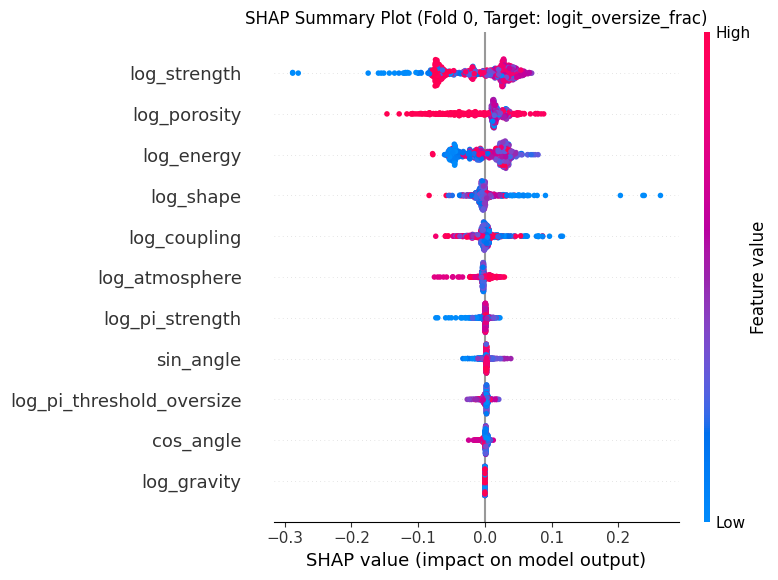

In [10]:
summary_fold = 0
entry = shap_history.get(summary_fold)
if entry is None:
    print(f"No SHAP values found for fold={summary_fold}. Run the CV loop first.")
else:
    shap.summary_plot(entry["values"], entry["features"], show=False)
    plt.title(f"SHAP Summary Plot (Fold {summary_fold}, Target: {TARGET})")
    plt.tight_layout()
    plt.savefig(f"../output/oversize_frac/shap_summary.png", dpi=150)
    plt.show()

### LightGBM convergence plot

Saved convergence plot


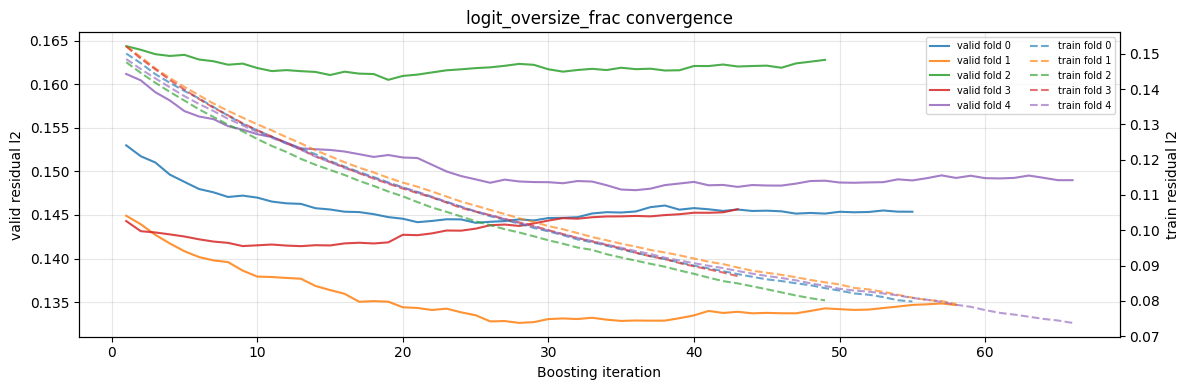

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
train_ax = ax.twinx()
for fold in range(n_splits):
    hist = convergence_history.get(fold)
    if hist is None:
        continue
    train_l2 = hist["train_residual"]["l2"]
    valid_l2 = hist["valid_residual"]["l2"]
    iters = np.arange(1, len(valid_l2) + 1)
    color = f"C{fold}"
    ax.plot(iters, valid_l2, color=color, linestyle="-", alpha=0.85, label=f"valid fold {fold}")
    train_ax.plot(iters, train_l2, color=color, linestyle="--", alpha=0.65, label=f"train fold {fold}")
ax.set_title(f"{TARGET} convergence")
ax.set_ylabel("valid residual l2")
ax.set_xlabel("Boosting iteration")
train_ax.set_ylabel("train residual l2")
ax.grid(True, alpha=0.3)
valid_handles, valid_labels = ax.get_legend_handles_labels()
train_handles, train_labels = train_ax.get_legend_handles_labels()
train_ax.legend(valid_handles + train_handles, valid_labels + train_labels, loc="best", fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig("../output/oversize_frac/lgbm_convergence.png", dpi=150)
print("Saved convergence plot")
plt.show()

### Mean CV metrics (physical units)

In [12]:
print("=== Train Metrics ===")
print(f"Mean Train RMSE: {np.mean(train_rmse):.4f} ± {np.std(train_rmse):.4f}")
print(f"Mean Train MAE:  {np.mean(train_mae):.4f} ± {np.std(train_mae):.4f}")
print(f"Mean Train R²:   {np.mean(train_r2):.4f} ± {np.std(train_r2):.4f}")
print("\n=== Validation Metrics ===")
print(f"Mean CV RMSE:    {np.mean(cv_rmse):.4f} ± {np.std(cv_rmse):.4f}")
print(f"Mean CV MAE:     {np.mean(cv_mae):.4f} ± {np.std(cv_mae):.4f}")
print(f"Mean CV MAPE:    {np.mean(cv_mape):.2f}% ± {np.std(cv_mape):.2f}%")
print(f"Mean CV R²:      {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"Mean CV F1:      {np.mean(cv_f1):.4f} ± {np.std(cv_f1):.4f}")

Mean CV RMSE:  0.0365 ± 0.0011
Mean CV MAPE:  20.39% ± 1.69%
Mean CV R²:    0.9898 ± 0.0007
Mean CV F1:    0.9720 ± 0.0052


### CV metric plot

In [ ]:
fold_idx = np.arange(n_splits)
fig, axes = plt.subplots(5, 1, figsize=(10, 14), sharex=True)
ax_rmse, ax_mae, ax_mape, ax_r2, ax_f1 = axes

ax_rmse.plot(fold_idx, train_rmse, marker="s", label="Train", linestyle="--")
ax_rmse.plot(fold_idx, cv_rmse, marker="o", label="Validation")
ax_rmse.set_ylabel("RMSE")
ax_rmse.set_title("oversize_frac RMSE by fold")
ax_rmse.legend()

ax_mae.plot(fold_idx, train_mae, marker="s", label="Train", linestyle="--")
ax_mae.plot(fold_idx, cv_mae, marker="o", label="Validation")
ax_mae.set_ylabel("MAE")
ax_mae.set_title("oversize_frac MAE by fold")
ax_mae.legend()

ax_mape.plot(fold_idx, cv_mape, marker="o", label="Validation")
ax_mape.set_ylabel("MAPE (%)")
ax_mape.set_title("oversize_frac MAPE by fold")
ax_mape.legend()

ax_r2.plot(fold_idx, train_r2, marker="s", label="Train", linestyle="--")
ax_r2.plot(fold_idx, cv_r2, marker="o", label="Validation")
ax_r2.set_ylabel("R²")
ax_r2.set_title("oversize_frac R² by fold")
ax_r2.legend()

ax_f1.plot(fold_idx, cv_f1, marker="o", label="Validation")
ax_f1.set_xlabel("Fold")
ax_f1.set_ylabel("F1")
ax_f1.set_title("oversize_frac F1 by fold (median split)")
ax_f1.legend()

for ax in axes:
    ax.grid(True, alpha=0.3)
ax_f1.set_xticks(fold_idx)
plt.tight_layout()
plt.savefig("../output/oversize_frac/cv_metrics.png", dpi=150)
print("Saved cv_metrics.png")
plt.show()

### Best iterations from early stopping

In [14]:
final_n_estimators = int(np.median(best_iterations))
print(f"{TARGET}: folds={best_iterations}, median_for_final_fit={final_n_estimators}")

logit_oversize_frac: folds=[25, 28, 19, 13, 36], median_for_final_fit=25


### Fit final model on full data

In [15]:
final_model = HybridPhysicsModel(
    linear_features=LINEAR_FEATURES,
    lgb_features=LGB_FEATURES,
    lgb_params={
        "n_estimators": final_n_estimators,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "min_child_samples": 10,
        "reg_alpha": 0.1,
        "reg_lambda": 0.1,
        "verbose": -1,
    },
).fit(X, y)
print(f"\n{TARGET} final n_estimators={final_n_estimators} baseline coefficients:")
print(final_model.baseline_coefficients())


logit_oversize_frac final n_estimators=25 baseline coefficients:
log_pi_strength              4.339012
log_coupling                -0.921803
log_porosity                -0.015522
log_shape                    0.017596
sin_angle                    0.235507
cos_angle                    0.425301
log_pi_threshold_oversize    3.043433
dtype: float64


### Save trained model

In [16]:
import os
os.makedirs("../models", exist_ok=True)
joblib.dump(final_model, "../models/model_oversize_frac.joblib")
joblib.dump(z_log, "../models/z_log_oversize_frac.joblib")

['model_oversize_frac.joblib']